# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the Loan Prediction dataset to understand the data distribution, detect missing values, and identify relationships between features and loan approval status.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)
n = 500

df = pd.DataFrame({
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Married': np.random.choice(['Yes', 'No'], n),
    'Dependents': np.random.choice(['0','1','2','3+'], n),
    'Education': np.random.choice(['Graduate','Not Graduate'], n),
    'Self_Employed': np.random.choice(['Yes','No'], n),
    'ApplicantIncome': np.random.randint(1500,10000,n),
    'CoapplicantIncome': np.random.randint(0,5000,n),
    'LoanAmount': np.random.randint(50,500,n),
    'Loan_Amount_Term': np.random.choice([360,180,120,240], n),
    'Credit_History': np.random.choice([1.0,0.0], n),
    'Property_Area': np.random.choice(['Urban','Semiurban','Rural'], n),
    'Loan_Status': np.random.choice(['Y','N'], n)
})

df.to_csv("loan_data.csv", index=False)
print("Fake loan_data.csv created with 500 rows!")

Fake loan_data.csv created with 500 rows!


In [3]:
df = pd.read_csv("loan_data.csv")
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,Yes,9225,2355,116,360,1.0,Urban,Y
1,Female,Yes,2,Not Graduate,No,2026,4278,53,360,1.0,Urban,Y
2,Male,Yes,0,Not Graduate,No,4724,4724,491,120,1.0,Urban,N
3,Male,No,0,Graduate,No,3375,2557,458,240,0.0,Urban,Y
4,Male,Yes,0,Graduate,No,3263,545,352,180,1.0,Semiurban,Y


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (500, 12)


In [5]:
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             500 non-null    object 
 1   Married            500 non-null    object 
 2   Dependents         500 non-null    object 
 3   Education          500 non-null    object 
 4   Self_Employed      500 non-null    object 
 5   ApplicantIncome    500 non-null    int64  
 6   CoapplicantIncome  500 non-null    int64  
 7   LoanAmount         500 non-null    int64  
 8   Loan_Amount_Term   500 non-null    int64  
 9   Credit_History     500 non-null    float64
 10  Property_Area      500 non-null    object 
 11  Loan_Status        500 non-null    object 
dtypes: float64(1), int64(4), object(7)
memory usage: 47.0+ KB


In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,500.00000,500.000000,500.000000,500.000000,500.0000
mean,5718.11200,2417.254000,289.022000,227.280000,0.5200
std,2492.57919,1416.180491,133.568404,89.468491,0.5001
min,1501.00000,7.000000,50.000000,120.000000,0.0000
25%,3457.25000,1135.000000,172.500000,180.000000,0.0000
50%,5878.50000,2344.000000,300.500000,240.000000,1.0000
75%,7948.50000,3649.000000,406.000000,360.000000,1.0000
max,9967.00000,4998.000000,499.000000,360.000000,1.0000


In [8]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

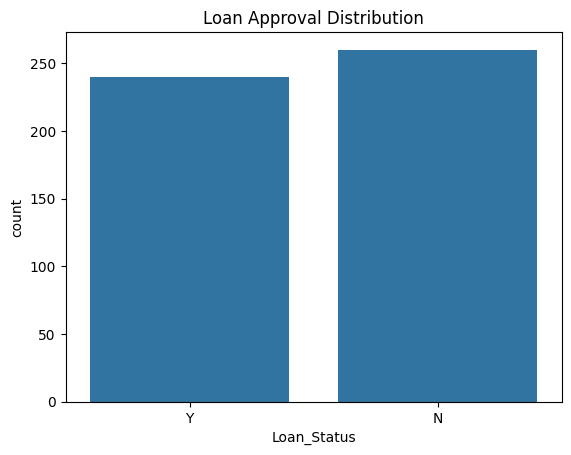

In [9]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

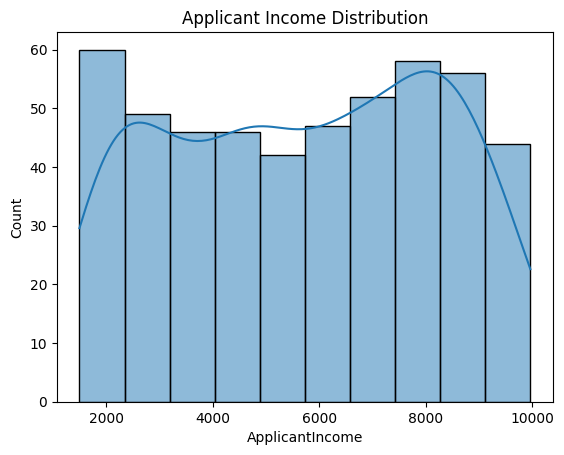

In [10]:
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

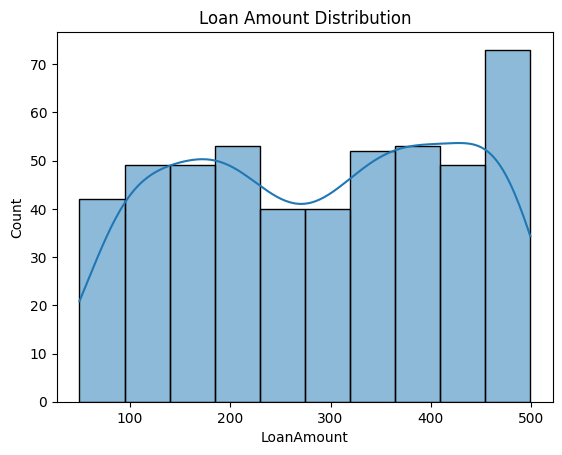

In [11]:
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

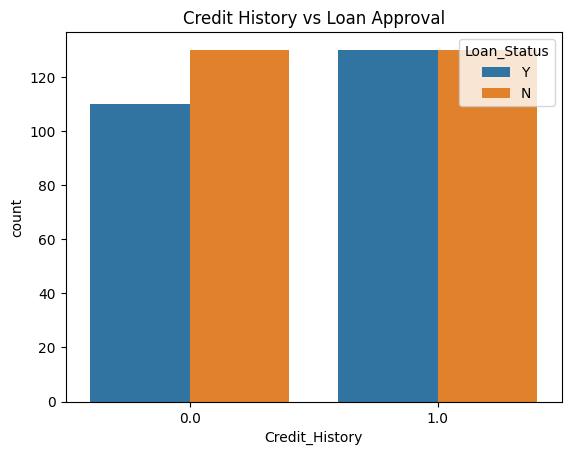

In [12]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Approval")
plt.show()

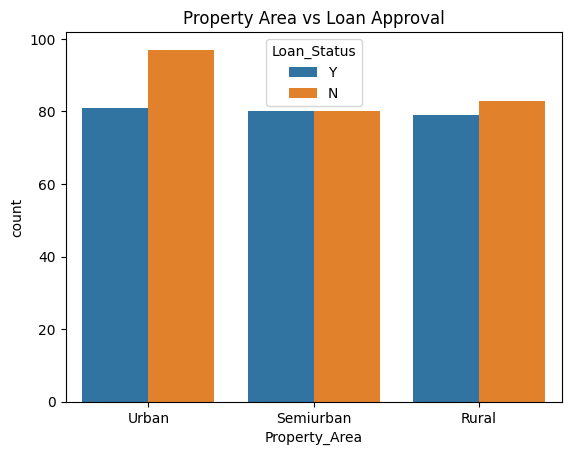

In [13]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Property Area vs Loan Approval")
plt.show()

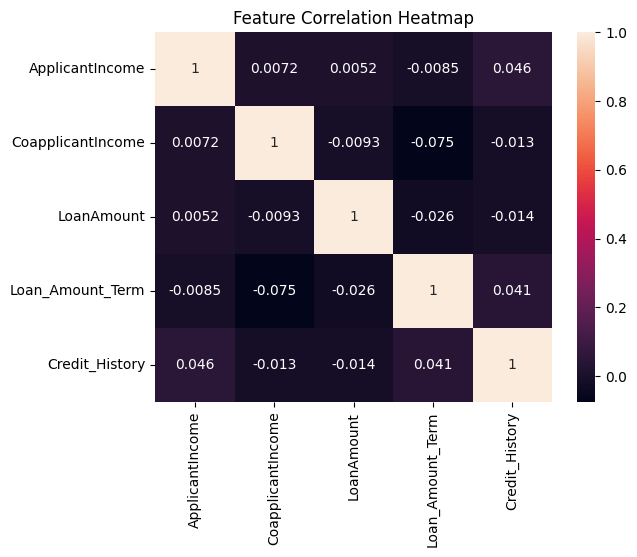

In [14]:
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

## EDA Conclusion

From the exploratory data analysis, several insights can be observed:

- Applicants with a valid credit history have a higher chance of loan approval.
- Higher applicant income generally increases approval probability.
- Loan approval rates vary across property areas.
- Some columns contain missing values that will need to be handled during preprocessing.

These insights help guide the preprocessing and modeling steps in the main notebook.